In [ ]:
# train_traditional_models.py
import os
import joblib
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report
)
from sklearn.calibration import CalibratedClassifierCV

from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

# ---------------------------------------------------
# 1. Load unified dataset (features already extracted)
# ---------------------------------------------------
df = pd.read_csv("data/processed/train_rebuilt.csv").fillna(0)

X = df.drop(columns=["url", "tld", "label"], errors="ignore")
y = df["label"]

print(f"[INFO] Full dataset shape: {X.shape}, positives={y.sum()}, negatives={(y==0).sum()}")

# ---------------------------------------------------
# 2. Train/test split (70/30, stratified)
# ---------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)

print(f"[INFO] Train shape: {X_train.shape}, Test shape: {X_test.shape}")

os.makedirs("model", exist_ok=True)

# ---------------------------------------------------
# Helper: compute full metrics
# ---------------------------------------------------
def compute_metrics(name, model, X_te, y_te):
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]

    return {
        "model": name,
        "accuracy": accuracy_score(y_te, y_pred),
        "precision": precision_score(y_te, y_pred),
        "recall": recall_score(y_te, y_pred),
        "f1": f1_score(y_te, y_pred),
        "roc_auc": roc_auc_score(y_te, y_prob),
    }

metrics = []

# ---------------------------------------------------
# 3. RANDOM FOREST (base + calibrated)
# ---------------------------------------------------
print("\n[*] Training base Random Forest...")
rf_base = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    n_jobs=-1,
    random_state=42,
    class_weight="balanced",
)
rf_base.fit(X_train, y_train)
joblib.dump(rf_base, "model/rf_base.pkl")
print("[+] Saved base RF → model/rf_base.pkl")

metrics.append(compute_metrics("RF_base", rf_base, X_test, y_test))

print("\n[*] Calibrating RF...")
rf_cal = CalibratedClassifierCV(rf_base, method="isotonic", cv=3)
rf_cal.fit(X_train, y_train)
joblib.dump(rf_cal, "model/new_rf_calibrated.pkl")
print("[+] Saved calibrated RF → model/new_rf_calibrated.pkl")

metrics.append(compute_metrics("RF_calibrated", rf_cal, X_test, y_test))

# ---------------------------------------------------
# 4. LIGHTGBM (base + calibrated)
# ---------------------------------------------------
print("\n[*] Training base LightGBM...")
lgb_base = LGBMClassifier(
    n_estimators=400,
    learning_rate=0.05,
    num_leaves=64,
    random_state=42,
    class_weight="balanced",
)
lgb_base.fit(X_train, y_train)
joblib.dump(lgb_base, "model/lgbm_base.pkl")
metrics.append(compute_metrics("LGBM_base", lgb_base, X_test, y_test))

print("\n[*] Calibrating LGBM...")
lgb_cal = CalibratedClassifierCV(lgb_base, method="isotonic", cv=3)
lgb_cal.fit(X_train, y_train)
joblib.dump(lgb_cal, "model/new_lgbm_calibrated.pkl")
metrics.append(compute_metrics("new_LGBM_calibrated", lgb_cal, X_test, y_test))

# ---------------------------------------------------
# 5. XGBOOST (base + calibrated)
# ---------------------------------------------------
print("\n[*] Training base XGBoost...")
xgb_base = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    n_estimators=300,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
)
xgb_base.fit(X_train, y_train)
joblib.dump(xgb_base, "model/xgb_base.pkl")
metrics.append(compute_metrics("XGB_base", xgb_base, X_test, y_test))

print("\n[*] Calibrating XGB...")
xgb_cal = CalibratedClassifierCV(xgb_base, method="sigmoid", cv=3)
xgb_cal.fit(X_train, y_train)
joblib.dump(xgb_cal, "model/new_xgb_calibrated.pkl")
metrics.append(compute_metrics("new_XGB_calibrated", xgb_cal, X_test, y_test))

# ---------------------------------------------------
# 6. Save metrics summary for later plotting
# ---------------------------------------------------
metrics_df = pd.DataFrame(metrics)
metrics_df.to_csv("model/traditional_metrics_pre_post_calibration.csv", index=False)

print("\n[+] Saved full metrics summary → model/traditional_metrics_pre_post_calibration.csv")
print(metrics_df)


In [ ]:
import os
import joblib
import pandas as pd
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score
)

# ---------------------------------------------------
# Load dataset
# ---------------------------------------------------
df = pd.read_csv("data/processed/train_rebuilt.csv").fillna(0)
X = df.drop(columns=["url", "tld", "label"], errors="ignore")
y = df["label"]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)

# ---------------------------------------------------
# Metrics helper
# ---------------------------------------------------
def compute_metrics(name, model):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    return {
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_prob),
    }

metrics = []

# ---------------------------------------------------
# Load & evaluate Random Forest
# ---------------------------------------------------
print("[INFO] Loading RF models...")
rf_base = joblib.load("model/rf_base.pkl")
rf_cal = joblib.load("model/new_rf_calibrated.pkl")

metrics.append(compute_metrics("RF_base", rf_base))
metrics.append(compute_metrics("RF_calibrated", rf_cal))

# ---------------------------------------------------
# Load & evaluate LightGBM (base only)
# ---------------------------------------------------
print("[INFO] Loading LGBM base...")
lgb_base = joblib.load("model/lgbm_base.pkl")
metrics.append(compute_metrics("LGBM_base", lgb_base))

# ---------------------------------------------------
# Load & evaluate XGBoost (base only)
# ---------------------------------------------------
print("[INFO] Loading XGB base...")
xgb_base = joblib.load("model/xgb_base.pkl")
metrics.append(compute_metrics("XGB_base", xgb_base))

# ---------------------------------------------------
# Save results
# ---------------------------------------------------
metrics_df = pd.DataFrame(metrics)
metrics_df.to_csv("model/traditional_metrics_pre_post_calibration.csv", index=False)

print("\n[+] Saved → traditional_metrics_pre_post_calibration.csv")
print(metrics_df)


In [ ]:
#  COMPARISON PLOTS USING MATPLOTLIB / SEABORN

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("model/traditional_metrics_pre_post_calibration.csv")

metrics = ["accuracy", "precision", "recall", "f1", "roc_auc"]

for m in metrics:
    plt.figure(figsize=(8,6))
    sns.barplot(data=df, x="model", y=m, palette="viridis")
    plt.title(f"{m.upper()} — Base vs Calibrated")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


In [ ]:
import pandas as pd
df = pd.read_csv("data/test.csv")
print(df.columns)


In [ ]:
# eval_raw_dl_models.py
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import pytorch_lightning as pl
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report, confusion_matrix
)

os.makedirs("model", exist_ok=True)
os.makedirs("plot1s", exist_ok=True)
DEVICE = "cpu"
MAX_LEN = 200  # same as training

# =========================================================
# Dataset (same as in train_dl_models.py)
# =========================================================
class URLCharDataset(Dataset):
    def __init__(self, urls, labels, max_len=MAX_LEN):
        self.max_len = max_len
        self.labels = torch.tensor(labels.values, dtype=torch.float32)
        self.urls = [self._encode(u) for u in urls.astype(str).values]

    def _encode(self, url):
        s = url[:self.max_len].ljust(self.max_len)
        return torch.tensor([min(ord(c), 127) for c in s], dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, i):
        return self.urls[i], self.labels[i]

# =========================================================
# Models (same definitions as train_dl_models.py)
# =========================================================
class CNNPD(pl.LightningModule):
    def __init__(self, vocab_size=128, emb_dim=32, max_len=MAX_LEN, lr=1e-3):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, emb_dim)
        self.convs = nn.ModuleList(
            [nn.Conv1d(emb_dim, 64, 5, padding=2, dilation=d) for d in [1, 2, 4, 8]]
        )
        self.act = nn.LeakyReLU(0.1)
        self.pool = nn.AdaptiveMaxPool1d(1)
        self.fc = nn.Sequential(
            nn.Linear(64 * 4, 128),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.4),
            nn.Linear(128, 1),
        )
        self.loss = nn.BCEWithLogitsLoss()
        self.lr = lr

    def forward(self, x):
        x = self.emb(x).transpose(1, 2)
        feats = [self.pool(self.act(c(x))).squeeze(-1) for c in self.convs]
        z = torch.cat(feats, dim=1)
        return self.fc(z).squeeze(-1)


class BiGRU(pl.LightningModule):
    def __init__(self, vocab_size=128, emb_dim=32, hid=64, lr=1e-3):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, emb_dim)
        self.rnn = nn.GRU(emb_dim, hid, batch_first=True, bidirectional=True)
        self.fc = nn.Sequential(
            nn.Linear(hid * 2, 128), nn.ReLU(), nn.Dropout(0.4), nn.Linear(128, 1)
        )
        self.loss = nn.BCEWithLogitsLoss()
        self.lr = lr

    def forward(self, x):
        x = self.emb(x)
        _, h = self.rnn(x)
        h = torch.cat((h[-2], h[-1]), dim=1)
        return self.fc(h).squeeze(-1)


class BiLSTM_GRU(pl.LightningModule):
    def __init__(self, vocab_size=128, emb_dim=32, hid=64, lr=1e-3):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, emb_dim)
        self.lstm = nn.LSTM(emb_dim, hid, batch_first=True, bidirectional=True)
        self.gru = nn.GRU(hid * 2, hid, batch_first=True, bidirectional=True)
        self.fc = nn.Sequential(
            nn.Linear(hid * 2, 128), nn.ReLU(), nn.Dropout(0.4), nn.Linear(128, 1)
        )
        self.loss = nn.BCEWithLogitsLoss()
        self.lr = lr

    def forward(self, x):
        x = self.emb(x)
        x, _ = self.lstm(x)
        _, h = self.gru(x)
        h = torch.cat((h[-2], h[-1]), dim=1)
        return self.fc(h).squeeze(-1)

# =========================================================
# Evaluation helper
# =========================================================
def eval_dl_model(name, ckpt_path, model_class):
    print(f"\n📊 Evaluating {name} on raw_test.csv ...")
    test = pd.read_csv("data/raw_test.csv")
    ds_test = URLCharDataset(test["url_norm"], test["label"])
    loader = DataLoader(ds_test, batch_size=512, shuffle=False)

    model = model_class.load_from_checkpoint(ckpt_path, map_location=DEVICE)
    model.eval()
    preds, targs = [], []

    with torch.no_grad():
        for x, y in loader:
            out = torch.sigmoid(model(x))
            preds.append(out.cpu())
            targs.append(y)

    y_prob = torch.cat(preds).numpy()
    y_true = torch.cat(targs).numpy()
    y_pred = (y_prob >= 0.5).astype(int)

    metrics = {
        "model": name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred),
        "recall": recall_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred),
        "roc_auc": roc_auc_score(y_true, y_prob),
    }

    print(classification_report(y_true, y_pred, digits=3))
    print("Confusion matrix:\n", confusion_matrix(y_true, y_pred))
    print("ROC-AUC:", metrics["roc_auc"])

    return metrics

# =========================================================
# Run all 3 raw-URL models
# =========================================================
if __name__ == "__main__":
    all_metrics = []
    all_metrics.append(
        eval_dl_model("BiGRU_raw", "model/bigru_lightning.ckpt", BiGRU)
    )
    all_metrics.append(
        eval_dl_model("BiLSTM_GRU_raw", "model/bilstm_gru_lightning.ckpt", BiLSTM_GRU)
    )
    all_metrics.append(
        eval_dl_model("CNNPD_raw", "model/cnnpd_lightning.ckpt", CNNPD)
    )

    df_metrics = pd.DataFrame(all_metrics)
    df_metrics.to_csv("model/deep_raw_metrics.csv", index=False)
    print("\n✅ Saved raw DL metrics → model/deep_raw_metrics.csv")
    print(df_metrics)


In [ ]:
import pandas as pd
import torch
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix

# Import correct models
from phishin_train_cnn import URLDataset, LightningCNN
from phishin_nlp_lstm import LightningLSTM       # <-- you MUST create/import this
from phishin_train_ffnn import LightningFFNN       # <-- you MUST create/import this

DEVICE = "cpu"
MAX_LEN = 200

def eval_feature_model(name, ckpt_path, model_class):
    print(f"\n📊 Evaluating {name}...")

    test = pd.read_csv("data/test.csv")
    ds_test = URLDataset(test["url"], test["label"], max_len=MAX_LEN)
    loader = DataLoader(ds_test, batch_size=512, shuffle=False)

    model = model_class.load_from_checkpoint(
        ckpt_path, lr=1e-3, map_location=DEVICE
    )
    model.eval()

    preds, targets = [], []

    with torch.no_grad():
        for x, y in loader:
            prob = torch.sigmoid(model(x))
            preds.append(prob.cpu())
            targets.append(y)

    y_prob = torch.cat(preds).numpy()
    y_true = torch.cat(targets).numpy()
    y_pred = (y_prob >= 0.5).astype(int)

    metrics = {
        "model": name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred),
        "recall": recall_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred),
        "roc_auc": roc_auc_score(y_true, y_prob),
    }

    print(classification_report(y_true, y_pred, digits=3))
    print(confusion_matrix(y_true, y_pred))
    print("ROC-AUC:", metrics["roc_auc"])
    return metrics


if __name__ == "__main__":
    all_metrics = []

    all_metrics.append(eval_feature_model(
        "CNN_feature", "models/cnn_lightning.ckpt", LightningCNN))

    all_metrics.append(eval_feature_model(
        "LSTM_feature", "models/lstm_lightning.ckpt", LightningLSTM))

    all_metrics.append(eval_feature_model(
        "FFNN_feature", "models/ffnn_lightning.ckpt", LightningFFNN))

    df = pd.DataFrame(all_metrics)
    df.to_csv("model/deep_feature_metrics.csv", index=False)

    print("\n✅ Saved → model/deep_feature_metrics.csv")
    print(df)


In [ ]:
# Evaluating

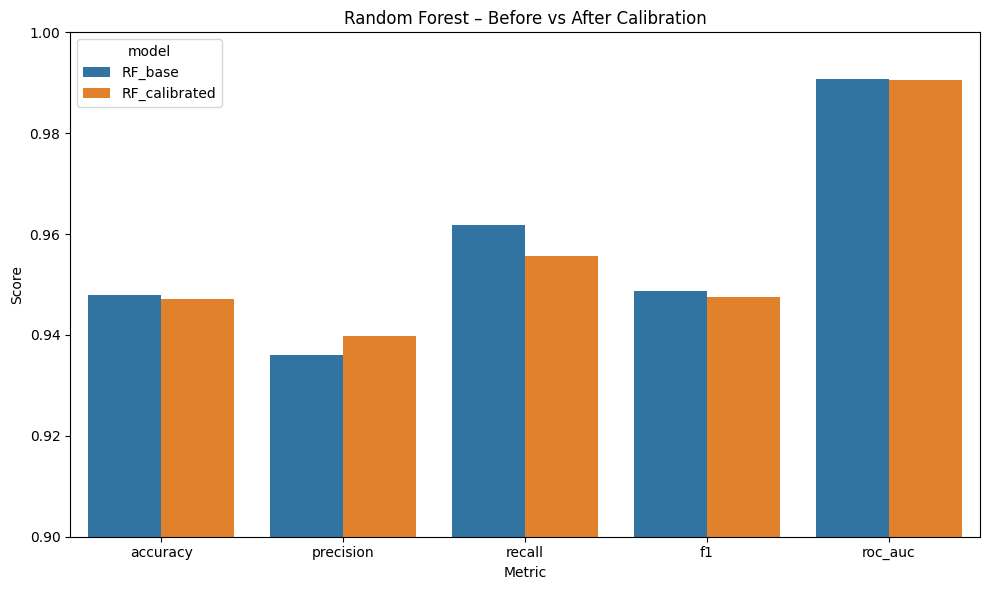

In [ ]:
# plot_rf_pre_post_calib.py
# RF base vs RF calibrated (per-metric bar chart)
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

trad = pd.read_csv("model/traditional_metrics_pre_post_calibration.csv")

rf = trad[trad["model"].isin(["RF_base", "RF_calibrated"])].copy()

metrics = ["accuracy", "precision", "recall", "f1", "roc_auc"]

plt.figure(figsize=(10, 6))
rf_melt = rf.melt(id_vars="model", value_vars=metrics,
                  var_name="metric", value_name="score")

sns.barplot(data=rf_melt, x="metric", y="score", hue="model")
plt.ylim(0.9, 1.0)
plt.title("Random Forest – Before vs After Calibration")
plt.ylabel("Score")
plt.xlabel("Metric")
plt.tight_layout()
plt.show()


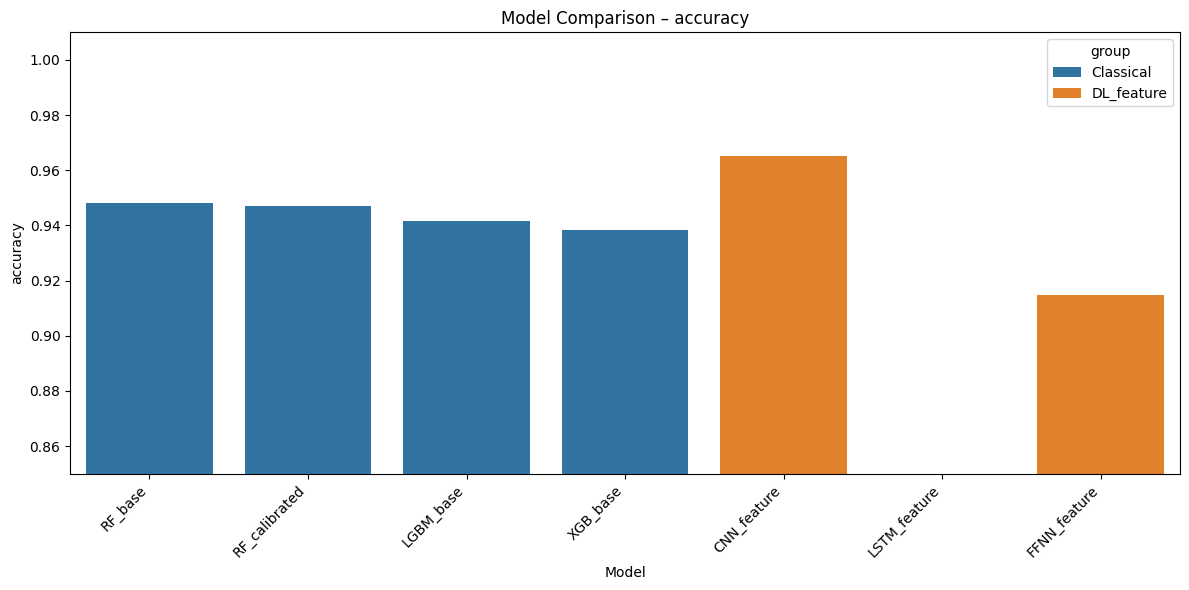

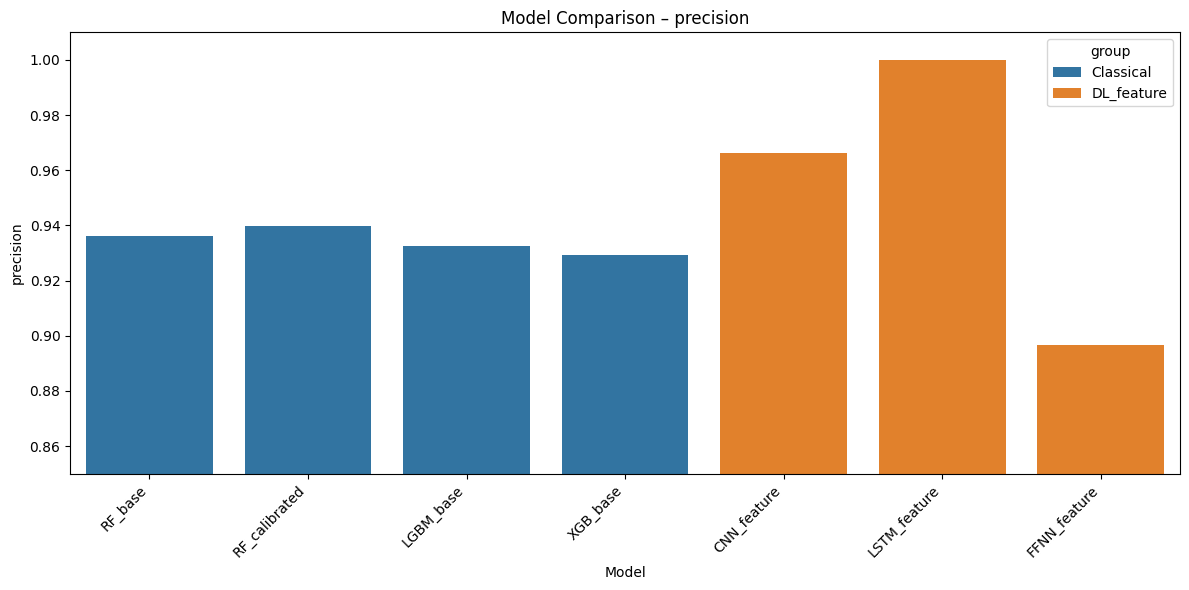

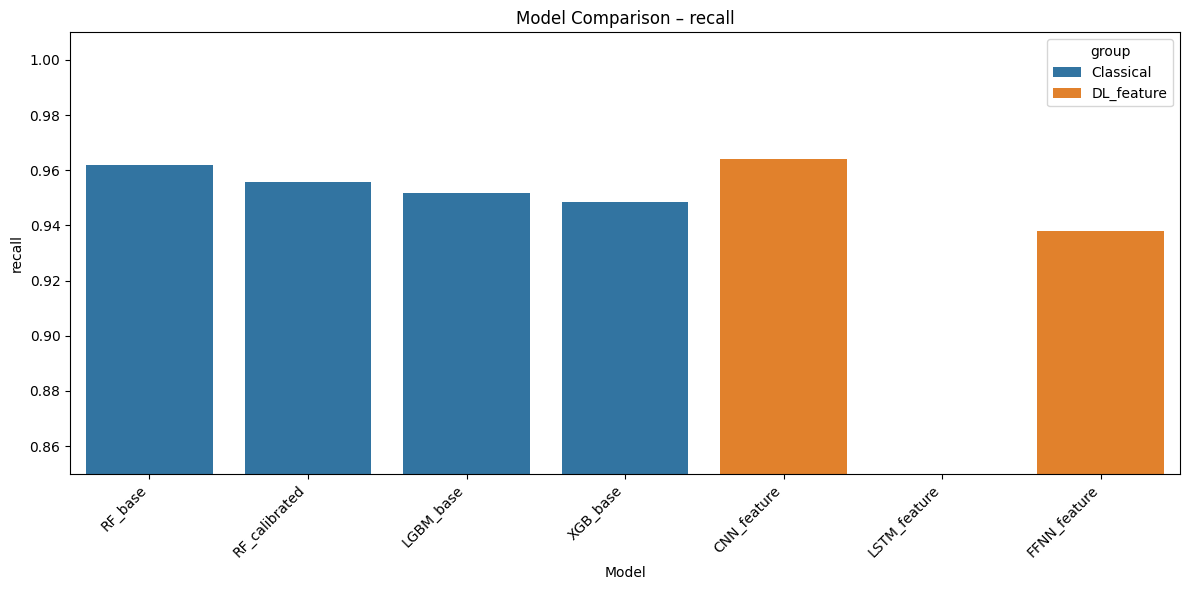

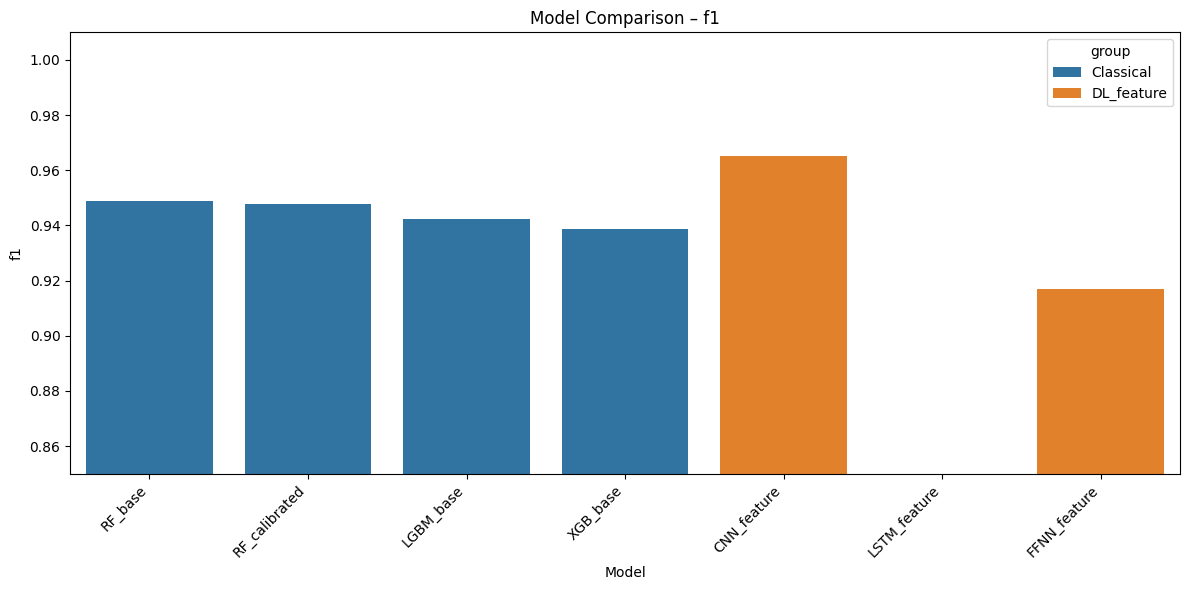

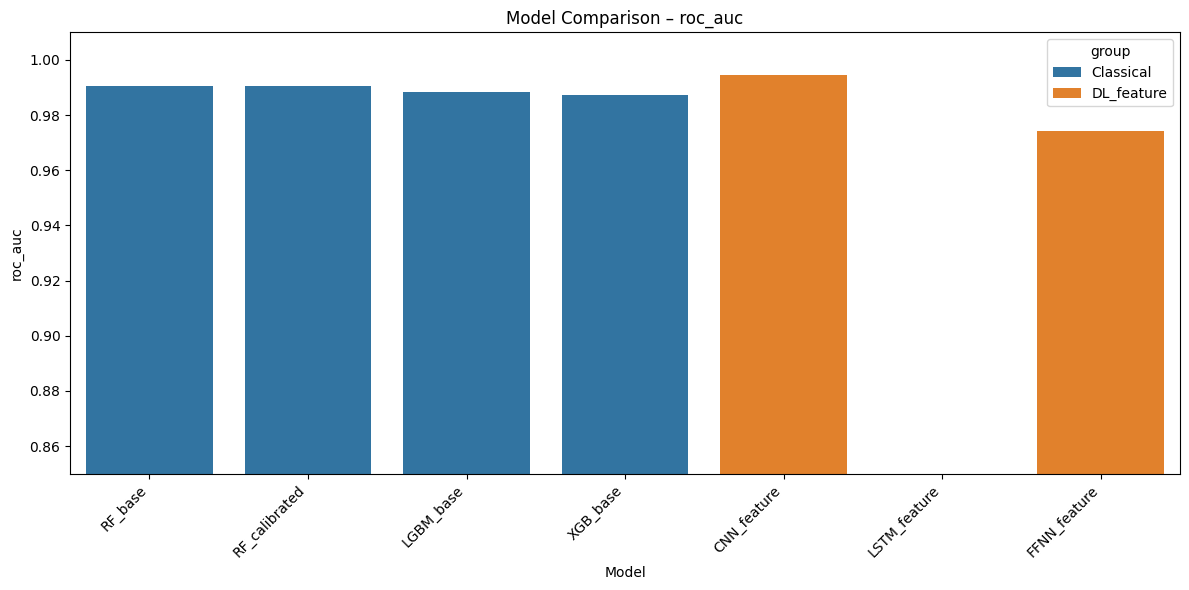

In [1]:
# Classical vs DL (feature-based) vs DL (raw) – per metric
# plot_all_models_comparison.py
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

trad = pd.read_csv("model/traditional_metrics_pre_post_calibration.csv")
deep_feat = pd.read_csv("model/deep_feature_metrics.csv")
# deep_raw = pd.read_csv("model/deep_raw_metrics.csv")

# Label groups
trad["group"] = "Classical"
deep_feat["group"] = "DL_feature"
# deep_raw["group"] = "DL_raw"

all_metrics = pd.concat([trad, deep_feat], ignore_index=True)

metrics = ["accuracy", "precision", "recall", "f1", "roc_auc"]

for m in metrics:
    plt.figure(figsize=(12, 6))
    sns.barplot(data=all_metrics, x="model", y=m, hue="group")
    plt.xticks(rotation=45, ha="right")
    plt.ylim(0.85, 1.01)
    plt.title(f"Model Comparison – {m}")
    plt.ylabel(m)
    plt.xlabel("Model")
    plt.tight_layout()
    plt.show()


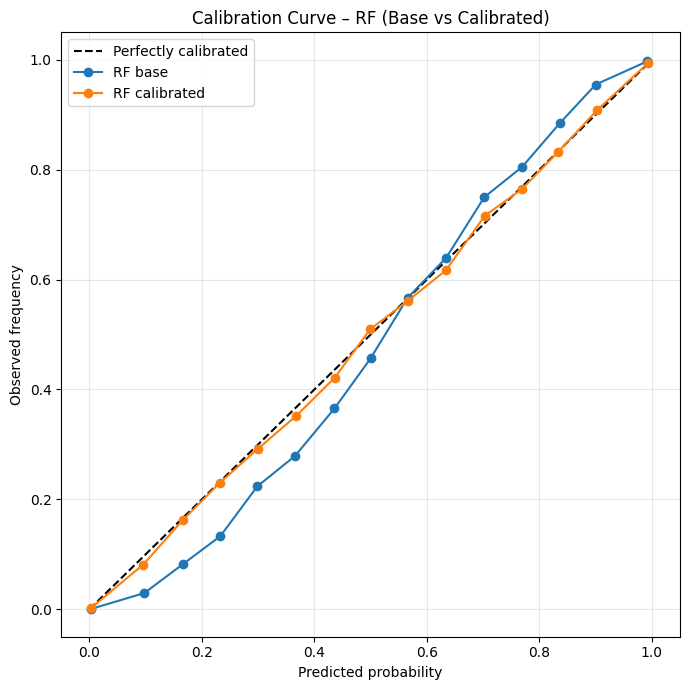

In [12]:
# Calibration curves (RF base vs RF calibrated)
# plot_rf_calibration_curve.py
import joblib
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.calibration import calibration_curve

df = pd.read_csv("data/processed/train_rebuilt.csv").fillna(0)
X = df.drop(columns=["url", "tld", "label"], errors="ignore")
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)

rf_base = joblib.load("model/rf_base.pkl")
rf_cal = joblib.load("model/new_rf_calibrated.pkl")  # your calibrated RF

prob_base = rf_base.predict_proba(X_test)[:, 1]
prob_cal = rf_cal.predict_proba(X_test)[:, 1]

frac_pos_base, mean_pred_base = calibration_curve(y_test, prob_base, n_bins=15)
frac_pos_cal,  mean_pred_cal  = calibration_curve(y_test, prob_cal,  n_bins=15)

plt.figure(figsize=(7,7))
plt.plot([0,1],[0,1],"k--", label="Perfectly calibrated")

plt.plot(mean_pred_base, frac_pos_base, "o-", label="RF base")
plt.plot(mean_pred_cal, frac_pos_cal,  "o-", label="RF calibrated")

plt.xlabel("Predicted probability")
plt.ylabel("Observed frequency")
plt.title("Calibration Curve – RF (Base vs Calibrated)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


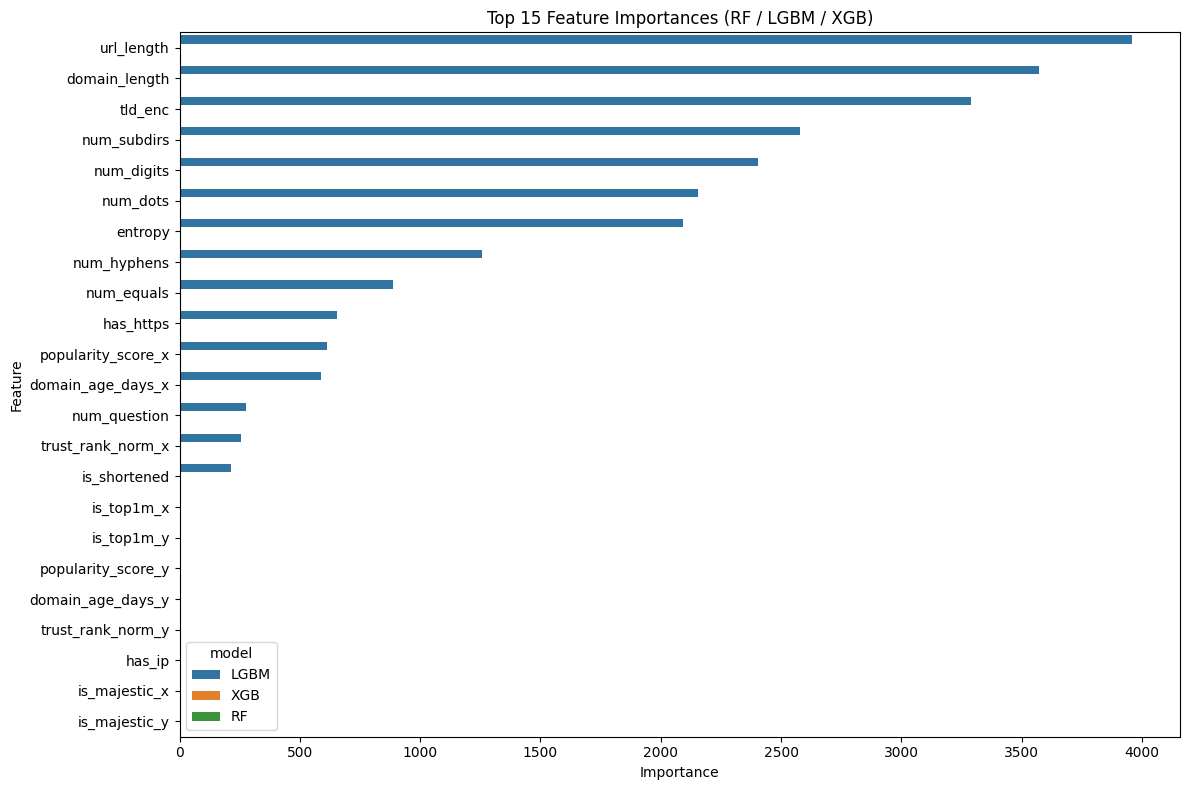

In [13]:
# Global feature importance (RF / LGBM / XGB)
# feature_importance_traditional.py
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv("data/processed/train_rebuilt.csv").fillna(0)
X = df.drop(columns=["url", "tld", "label"], errors="ignore")
feature_names = X.columns.tolist()

rf = joblib.load("model/rf_base.pkl")
lgb = joblib.load("model/lgbm_base.pkl")
xgb = joblib.load("model/xgb_base.pkl")

def get_importances(model, feat_names, model_name):
    if hasattr(model, "feature_importances_"):
        imp = model.feature_importances_
    elif hasattr(model, "booster_"):  # some XGB/LGBM variants
        imp = model.booster_.feature_importance()
    else:
        return None
    return pd.DataFrame({
        "model": model_name,
        "feature": feat_names,
        "importance": imp
    })

dfs = []
dfs.append(get_importances(rf, feature_names, "RF"))
dfs.append(get_importances(lgb, feature_names, "LGBM"))
dfs.append(get_importances(xgb, feature_names, "XGB"))

imp_all = pd.concat(dfs, ignore_index=True)

TOP_N = 15
imp_top = (
    imp_all.sort_values("importance", ascending=False)
           .groupby("model")
           .head(TOP_N)
)

plt.figure(figsize=(12, 8))
sns.barplot(
    data=imp_top,
    y="feature",
    x="importance",
    hue="model"
)
plt.title(f"Top {TOP_N} Feature Importances (RF / LGBM / XGB)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


⚙ Loading dataset…
⚙ Loading RandomForest model…
🔥 Preparing optimized SHAP sample…
🔥 Creating SHAP TreeExplainer…
🔥 Computing SHAP values (300 samples)…
📌 Using SHAP array format (extracting class 1)
📊 Plotting global SHAP summary…


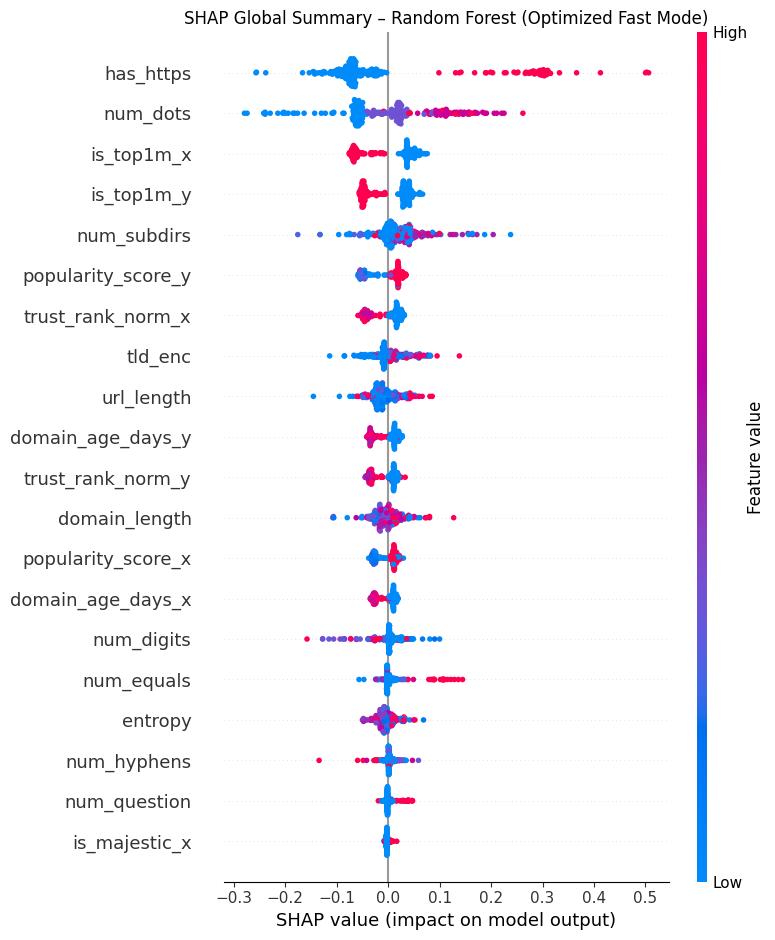

📊 Plotting SHAP Bar Plot…


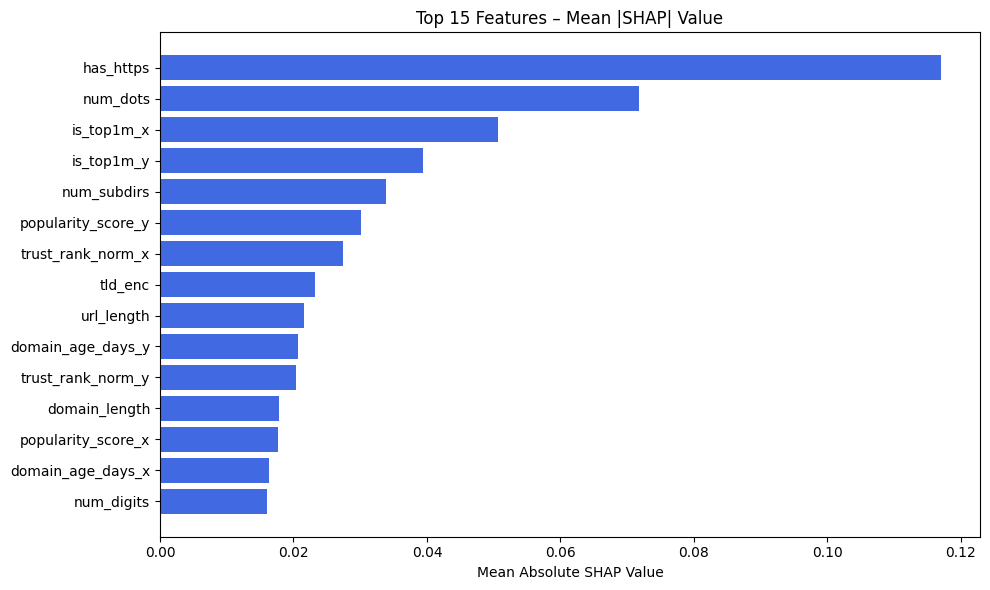

📊 Generating dependence plots…


<Figure size 700x500 with 0 Axes>

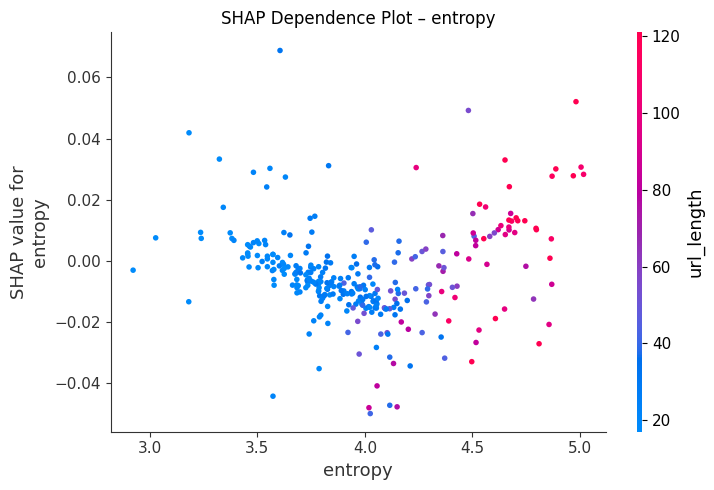

<Figure size 700x500 with 0 Axes>

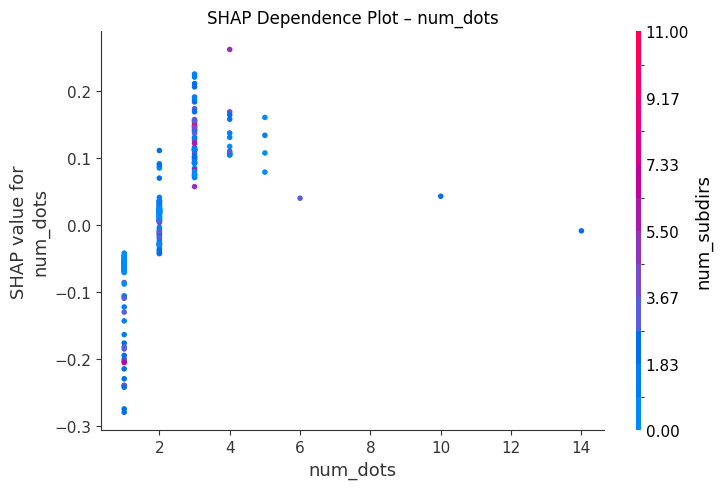

<Figure size 700x500 with 0 Axes>

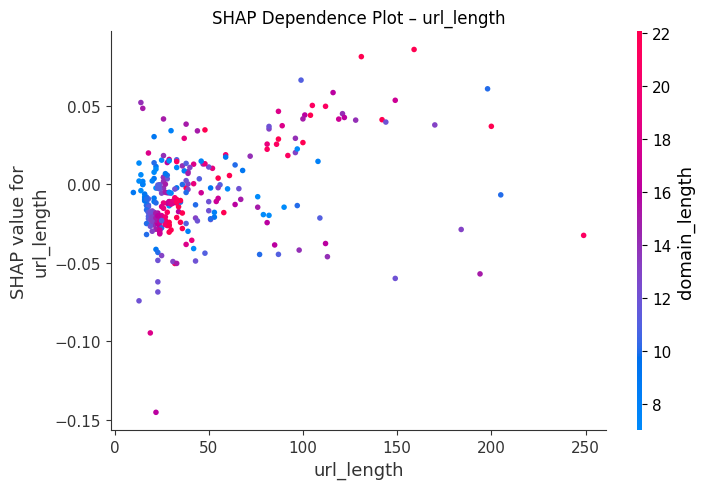

<Figure size 700x500 with 0 Axes>

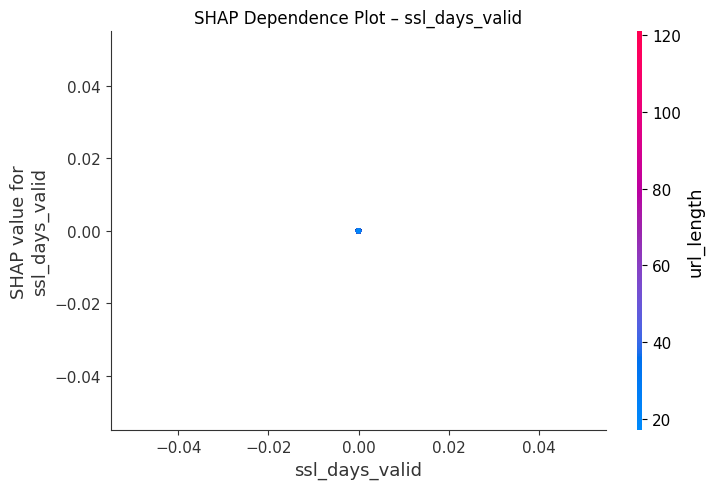

<Figure size 700x500 with 0 Axes>

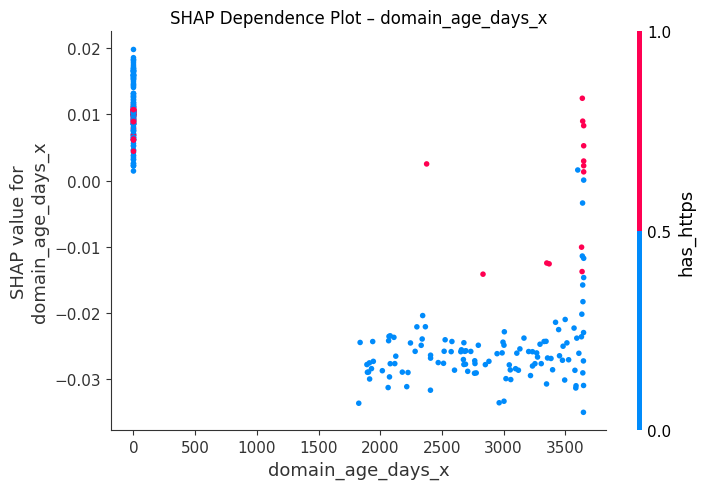

<Figure size 700x500 with 0 Axes>

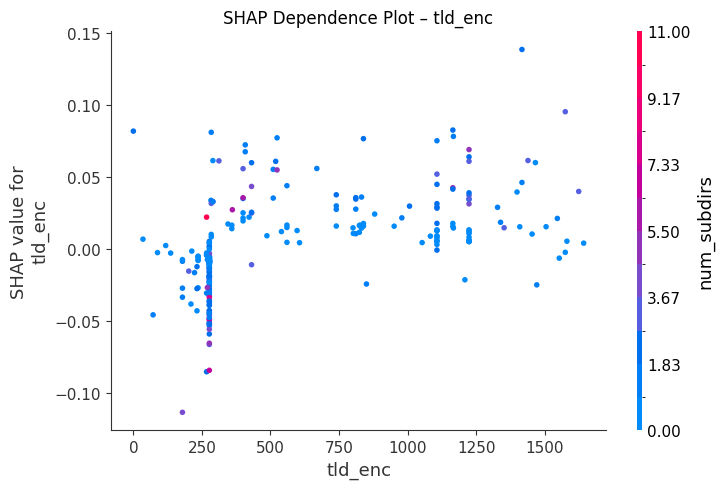

🔍 Selecting BENIGN example…


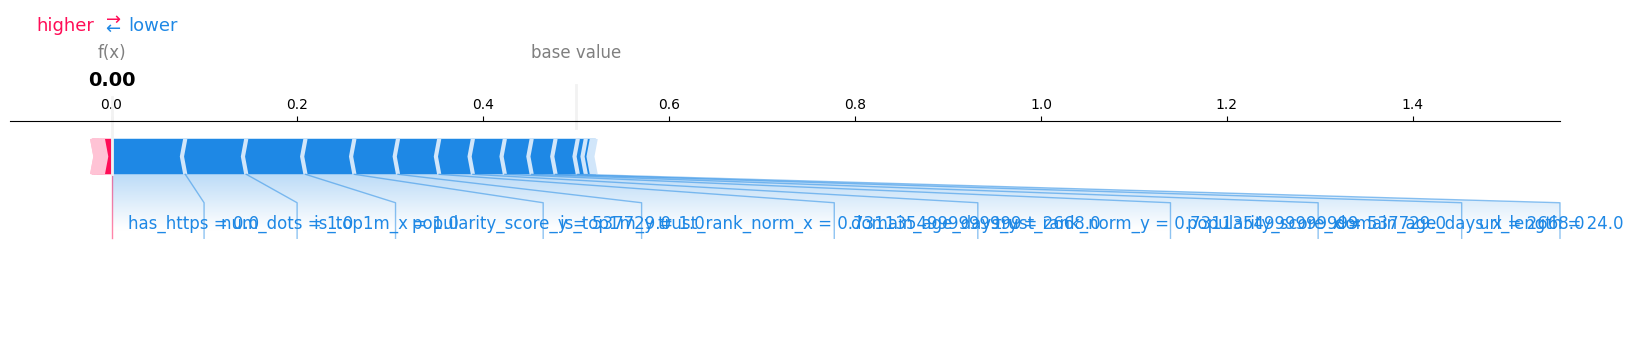

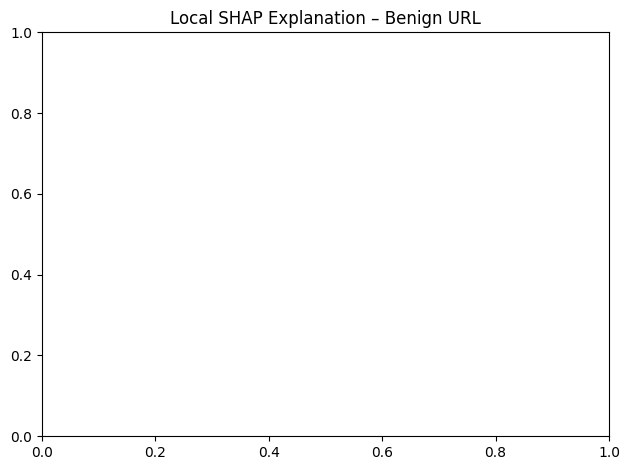

🔍 Selecting PHISHING example…


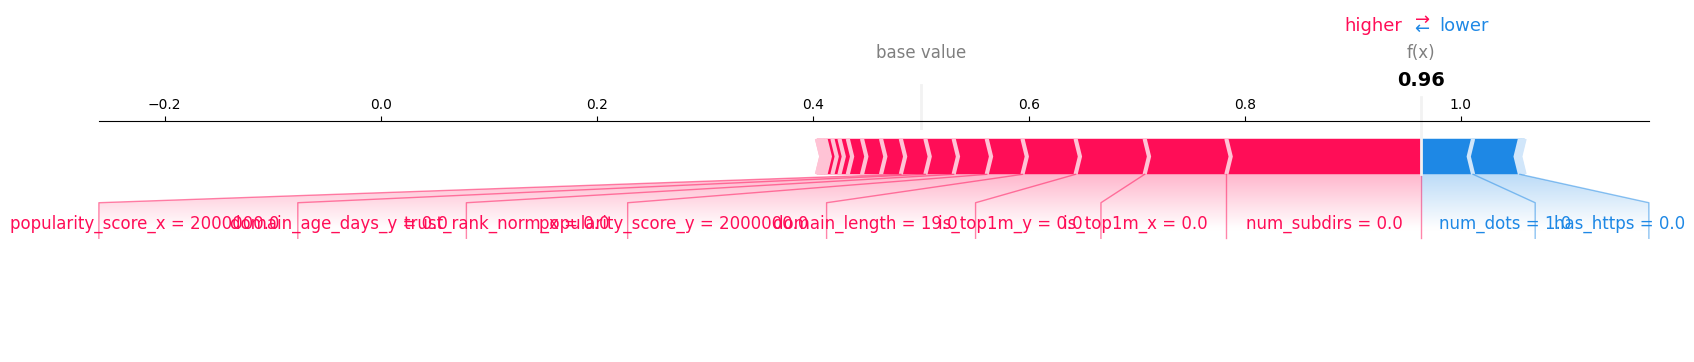

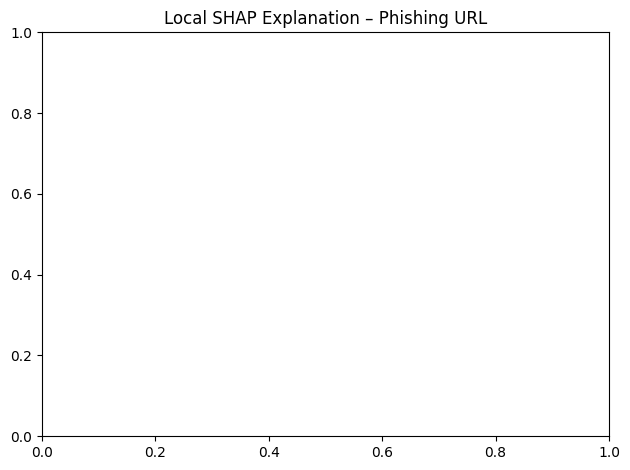


🎉 ALL SHAP EXPLANATIONS GENERATED SUCCESSFULLY!
📂 Saved to: plots/shap/


In [3]:
# ============================================================
# shap_rf_global_local_fast.py  (EXTENDED VERSION)
# Fast, stable SHAP interpretability for RandomForest
# + bar plots, dependence plots, and export
# ============================================================

import joblib
import pandas as pd
import shap
import matplotlib.pyplot as plt
import numpy as np
import os

os.makedirs("plots/shap", exist_ok=True)

print("⚙ Loading dataset…")
df = pd.read_csv("data/processed/train_rebuilt.csv").fillna(0)

# Keep only numeric features
X = df.drop(columns=["url", "tld", "label"], errors="ignore")
y = df["label"]
feature_names = X.columns.tolist()

print("⚙ Loading RandomForest model…")
rf = joblib.load("model/rf_base.pkl")

# ---------------------------------------------------
# 1. GLOBAL SHAP — Optimized Fast Mode
# ---------------------------------------------------
print("🔥 Preparing optimized SHAP sample…")
X_sample = X.sample(n=300, random_state=42)

print("🔥 Creating SHAP TreeExplainer…")
explainer = shap.TreeExplainer(
    rf,
    feature_perturbation="tree_path_dependent"
)

print("🔥 Computing SHAP values (300 samples)…")
raw_vals = explainer.shap_values(X_sample)

# Normalize SHAP output
if isinstance(raw_vals, list):
    print("📌 Using SHAP list format (class 1)")
    shap_values = raw_vals[1]
else:
    print("📌 Using SHAP array format (extracting class 1)")
    shap_values = raw_vals[:, :, 1]

# ---------------- GLOBAL SUMMARY ----------------
print("📊 Plotting global SHAP summary…")
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_sample,
                  feature_names=feature_names,
                  show=False)
plt.title("SHAP Global Summary – Random Forest (Optimized Fast Mode)")
plt.tight_layout()
plt.savefig("plots/shap/global_summary.png", dpi=300)
plt.savefig("plots/shap/global_summary.pdf")
plt.show()

# ---------------------------------------------------
# 1B. BAR PLOT – TOP FEATURES
# ---------------------------------------------------
print("📊 Plotting SHAP Bar Plot…")

# Compute mean(|shap|)
mean_abs_shap = np.mean(np.abs(shap_values), axis=0)
sorted_idx = np.argsort(mean_abs_shap)[::-1]

plt.figure(figsize=(10, 6))
plt.barh(
    np.array(feature_names)[sorted_idx][:15],
    mean_abs_shap[sorted_idx][:15],
    color="royalblue"
)
plt.gca().invert_yaxis()
plt.title("Top 15 Features – Mean |SHAP| Value")
plt.xlabel("Mean Absolute SHAP Value")
plt.tight_layout()
plt.savefig("plots/shap/top15_barplot.png", dpi=300)
plt.savefig("plots/shap/top15_barplot.pdf")
plt.show()

# ---------------------------------------------------
# 1C. DEPENDENCE PLOTS for Key Features
# ---------------------------------------------------
key_features = [
    "entropy",
    "num_dots",
    "url_length",
    "ssl_days_valid",
    "domain_age_days_x",
    "tld_enc"
]

print("📊 Generating dependence plots…")

for feat in key_features:
    if feat not in feature_names:
        print(f"⚠ Skipping {feat} (not in feature list)")
        continue
    plt.figure(figsize=(7, 5))
    shap.dependence_plot(
        feat,
        shap_values,
        X_sample,
        feature_names=feature_names,
        show=False
    )
    plt.title(f"SHAP Dependence Plot – {feat}")
    plt.tight_layout()
    plt.savefig(f"plots/shap/dep_{feat}.png", dpi=300)
    plt.savefig(f"plots/shap/dep_{feat}.pdf")
    plt.show()

# ---------------------------------------------------
# 2. LOCAL SHAP — BENIGN
# ---------------------------------------------------
print("🔍 Selecting BENIGN example…")
benign_row = df[df["label"] == 0].sample(1, random_state=10)
X_benign = benign_row.drop(columns=["url", "tld", "label"], errors="ignore")

local_benign_raw = explainer.shap_values(X_benign)
local_benign = local_benign_raw[1][0] if isinstance(local_benign_raw, list) else local_benign_raw[:, :, 1][0]

shap.force_plot(
    explainer.expected_value[1],
    local_benign,
    X_benign,
    feature_names=feature_names,
    matplotlib=True
)
plt.title("Local SHAP Explanation – Benign URL")
plt.tight_layout()
plt.savefig("plots/shap/local_benign.png", dpi=300)
plt.savefig("plots/shap/local_benign.pdf")
plt.show()

# ---------------------------------------------------
# 3. LOCAL SHAP — PHISHING
# ---------------------------------------------------
print("🔍 Selecting PHISHING example…")
phish_row = df[df["label"] == 1].sample(1, random_state=20)
X_phish = phish_row.drop(columns=["url", "tld", "label"], errors="ignore")

local_phish_raw = explainer.shap_values(X_phish)
local_phish = local_phish_raw[1][0] if isinstance(local_phish_raw, list) else local_phish_raw[:, :, 1][0]

shap.force_plot(
    explainer.expected_value[1],
    local_phish,
    X_phish,
    feature_names=feature_names,
    matplotlib=True
)
plt.title("Local SHAP Explanation – Phishing URL")
plt.tight_layout()
plt.savefig("plots/shap/local_phish.png", dpi=300)
plt.savefig("plots/shap/local_phish.pdf")
plt.show()

print("\n🎉 ALL SHAP EXPLANATIONS GENERATED SUCCESSFULLY!")
print("📂 Saved to: plots/shap/")


In [ ]:
# Local DL interpretability – Captum IG tokens
# captum_ig_example.py
import torch
from explain_dl_with_captumIG import top_substrings_ig

# Load your feature-based Lightning models
from phishin_train_cnn import LightningCNN
from phishin_train_ffnn import LightningFFNN

DEVICE = "cpu"

# ---------------------------------------------------------
# Example URL (you can replace this with any testing URL)
# ---------------------------------------------------------
TEST_URL = "http://testsafebrowsing.appspot.com/s/phishing.html"

# ---------------------------------------------------------
# (A) Captum IG for CNN_feature model
# ---------------------------------------------------------
CNN_CKPT = "models/cnn_lightning.ckpt"
cnn_model = LightningCNN.load_from_checkpoint(
    CNN_CKPT, map_location=DEVICE, lr=1e-3
).eval()

cnn_tokens = top_substrings_ig(cnn_model, TEST_URL, k=3)
print("\n🔍 Captum IG – CNN_feature")
print(cnn_tokens)

# ---------------------------------------------------------
# (B) Captum IG for FFNN_feature model
# ---------------------------------------------------------
FFNN_CKPT = "models/ffnn_lightning.ckpt"
ffnn_model = LightningFFNN.load_from_checkpoint(
    FFNN_CKPT, map_location=DEVICE, lr=1e-3
).eval()

ffnn_tokens = top_substrings_ig(ffnn_model, TEST_URL, k=3)
print("\n🔍 Captum IG – FFNN_feature")
print(ffnn_tokens)

print("\n✅ Captum IG extraction complete.")



Saved → model/calibration_metrics.csv
           model       ECE     Brier
0        RF_base  0.018097  0.038440
1  RF_calibrated  0.002292  0.037842


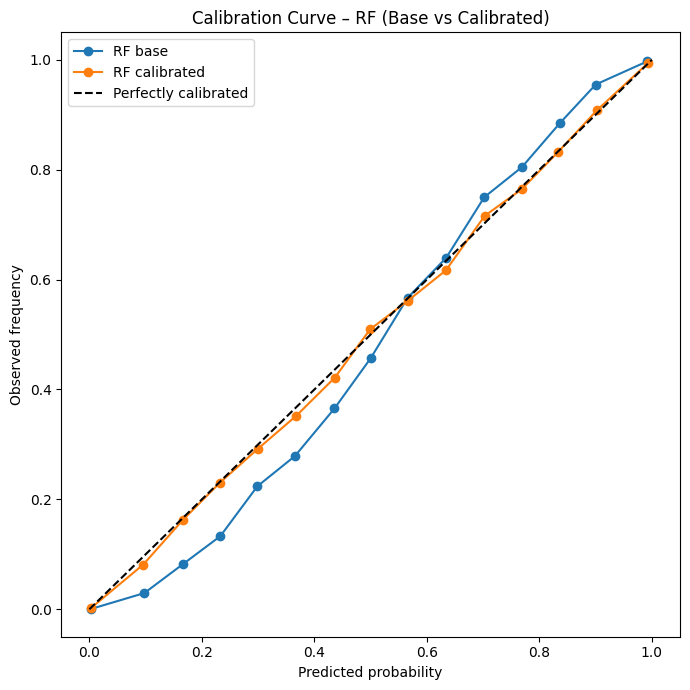


Calibration curve saved → plots/calibration_curve_rf.png


In [1]:
# ===========================================
# Calibration Metrics: Base vs Calibrated RF
# ===========================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import brier_score_loss
from sklearn.calibration import calibration_curve
import joblib
from sklearn.model_selection import train_test_split

# ---------------------------------------------
# Load dataset
# ---------------------------------------------
df = pd.read_csv("data/processed/train_rebuilt.csv").fillna(0)
X = df.drop(columns=["url", "tld", "label"], errors="ignore")
y = df["label"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# ---------------------------------------------
# Load models
# ---------------------------------------------
rf_base = joblib.load("model/rf_base.pkl")
rf_cal = joblib.load("model/new_rf_calibrated.pkl")

# ---------------------------------------------
# Get probability predictions
# ---------------------------------------------
p_base = rf_base.predict_proba(X_test)[:, 1]
p_cal = rf_cal.predict_proba(X_test)[:, 1]

# ---------------------------------------------
# ECE Metric
# ---------------------------------------------
def compute_ece(y_true, probs, n_bins=15):
    bins = np.linspace(0, 1, n_bins + 1)
    binids = np.digitize(probs, bins) - 1

    ece = 0.0
    for i in range(n_bins):
        idx = (binids == i)
        if np.sum(idx) == 0:
            continue
        avg_conf = np.mean(probs[idx])
        avg_acc = np.mean(y_true[idx])
        ece += np.abs(avg_conf - avg_acc) * (np.sum(idx) / len(probs))
    return ece

ece_base = compute_ece(y_test, p_base)
ece_cal = compute_ece(y_test, p_cal)

# ---------------------------------------------
# Brier score
# ---------------------------------------------
brier_base = brier_score_loss(y_test, p_base)
brier_cal = brier_score_loss(y_test, p_cal)

# ---------------------------------------------
# Save metrics
# ---------------------------------------------
metrics = pd.DataFrame([
    ["RF_base", ece_base, brier_base],
    ["RF_calibrated", ece_cal, brier_cal],
], columns=["model", "ECE", "Brier"])

metrics.to_csv("model/calibration_metrics.csv", index=False)
print("\nSaved → model/calibration_metrics.csv")
print(metrics)

# ---------------------------------------------
# Calibration curves (Reliability Diagrams)
# ---------------------------------------------
plt.figure(figsize=(7, 7))

for label, probs in [
    ("RF base", p_base),
    ("RF calibrated", p_cal)
]:
    frac_pos, mean_pred = calibration_curve(y_test, probs, n_bins=15)
    plt.plot(mean_pred, frac_pos, marker='o', label=label)

plt.plot([0, 1], [0, 1], "--", color="black", label="Perfectly calibrated")
plt.xlabel("Predicted probability")
plt.ylabel("Observed frequency")
plt.title("Calibration Curve – RF (Base vs Calibrated)")
plt.legend()
plt.tight_layout()
plt.savefig("plots/calibration_curve_rf.png", dpi=300)
plt.show()

print("\nCalibration curve saved → plots/calibration_curve_rf.png")
